# 5주차_데이터 탐색과 시각화 Ⅱ

- 시각화 실습

---

In [1]:
# https://www.kaggle.com/datasets/fivethirtyeight/uber-pickups-in-new-york-city?select=uber-raw-data-sep14.csv

In [1]:
# Uber NYC 데이터 시각화 템플릿 (Jupyter Notebook 용)

# 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display
import numpy as np
from pandas.plotting import parallel_coordinates

plt.rcParams['figure.dpi'] = 300

# 그래프 스타일 설정
sns.set(style="whitegrid")

In [2]:
FILE_PATH = "uber-raw-data-sep14.csv"
df = pd.read_csv(FILE_PATH)

df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


In [3]:
df.shape

(1028136, 4)

In [4]:
df.info()

# Date/Time : The date and time of the Uber pickup
# Lat : The latitude of the Uber pickup
# Lon : The longitude of the Uber pickup
# Base : The TLC base company code affiliated with the Uber pickup

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  object 
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  object 
dtypes: float64(2), object(2)
memory usage: 31.4+ MB


In [5]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [6]:
df.describe()

,Lat,Lon
count,1.028136e+06,1.028136e+06
mean,4.073922e+01,-7.397182e+01
std,4.082861e-02,5.831413e-02
min,3.998970e+01,-7.477360e+01
25%,4.072040e+01,-7.399620e+01
50%,4.074180e+01,-7.398310e+01
75%,4.076120e+01,-7.396280e+01
max,4.134760e+01,-7.271630e+01


In [7]:
df.select_dtypes(include=["number"]).skew()

Lat    0.461476
Lon    2.239341
dtype: float64

In [8]:
df.select_dtypes(include=["number"]).kurt()

Lat    10.180041
Lon    27.924359
dtype: float64

In [9]:
df.select_dtypes(include=["number"]).cov()

,Lat,Lon
Lat,0.001667,0.000110
Lon,0.000110,0.003401


In [10]:
df.select_dtypes(include=["number"]).corr(method="pearson")

,Lat,Lon
Lat,1.000000,0.046376
Lon,0.046376,1.000000


In [11]:
df["Date/Time"] = pd.to_datetime(df['Date/Time'])

df

,Date/Time,Lat,Lon,Base
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512
...,...,...,...,...
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764


In [12]:
df["hour"] = df["Date/Time"].dt.hour

df

,Date/Time,Lat,Lon,Base,hour
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0
...,...,...,...,...,...
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,22
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,22
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,22
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,22


In [13]:
df["day_of_week"] = df['Date/Time'].dt.day_name()

df

,Date/Time,Lat,Lon,Base,hour,day_of_week
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,Monday
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,Monday
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,Monday
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,Monday
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,Monday
...,...,...,...,...,...,...
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,22,Tuesday
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,22,Tuesday
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,22,Tuesday
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,22,Tuesday


## 1. 시간 시각화 – 시간대별 탑승 수 추세 (Line Plot)

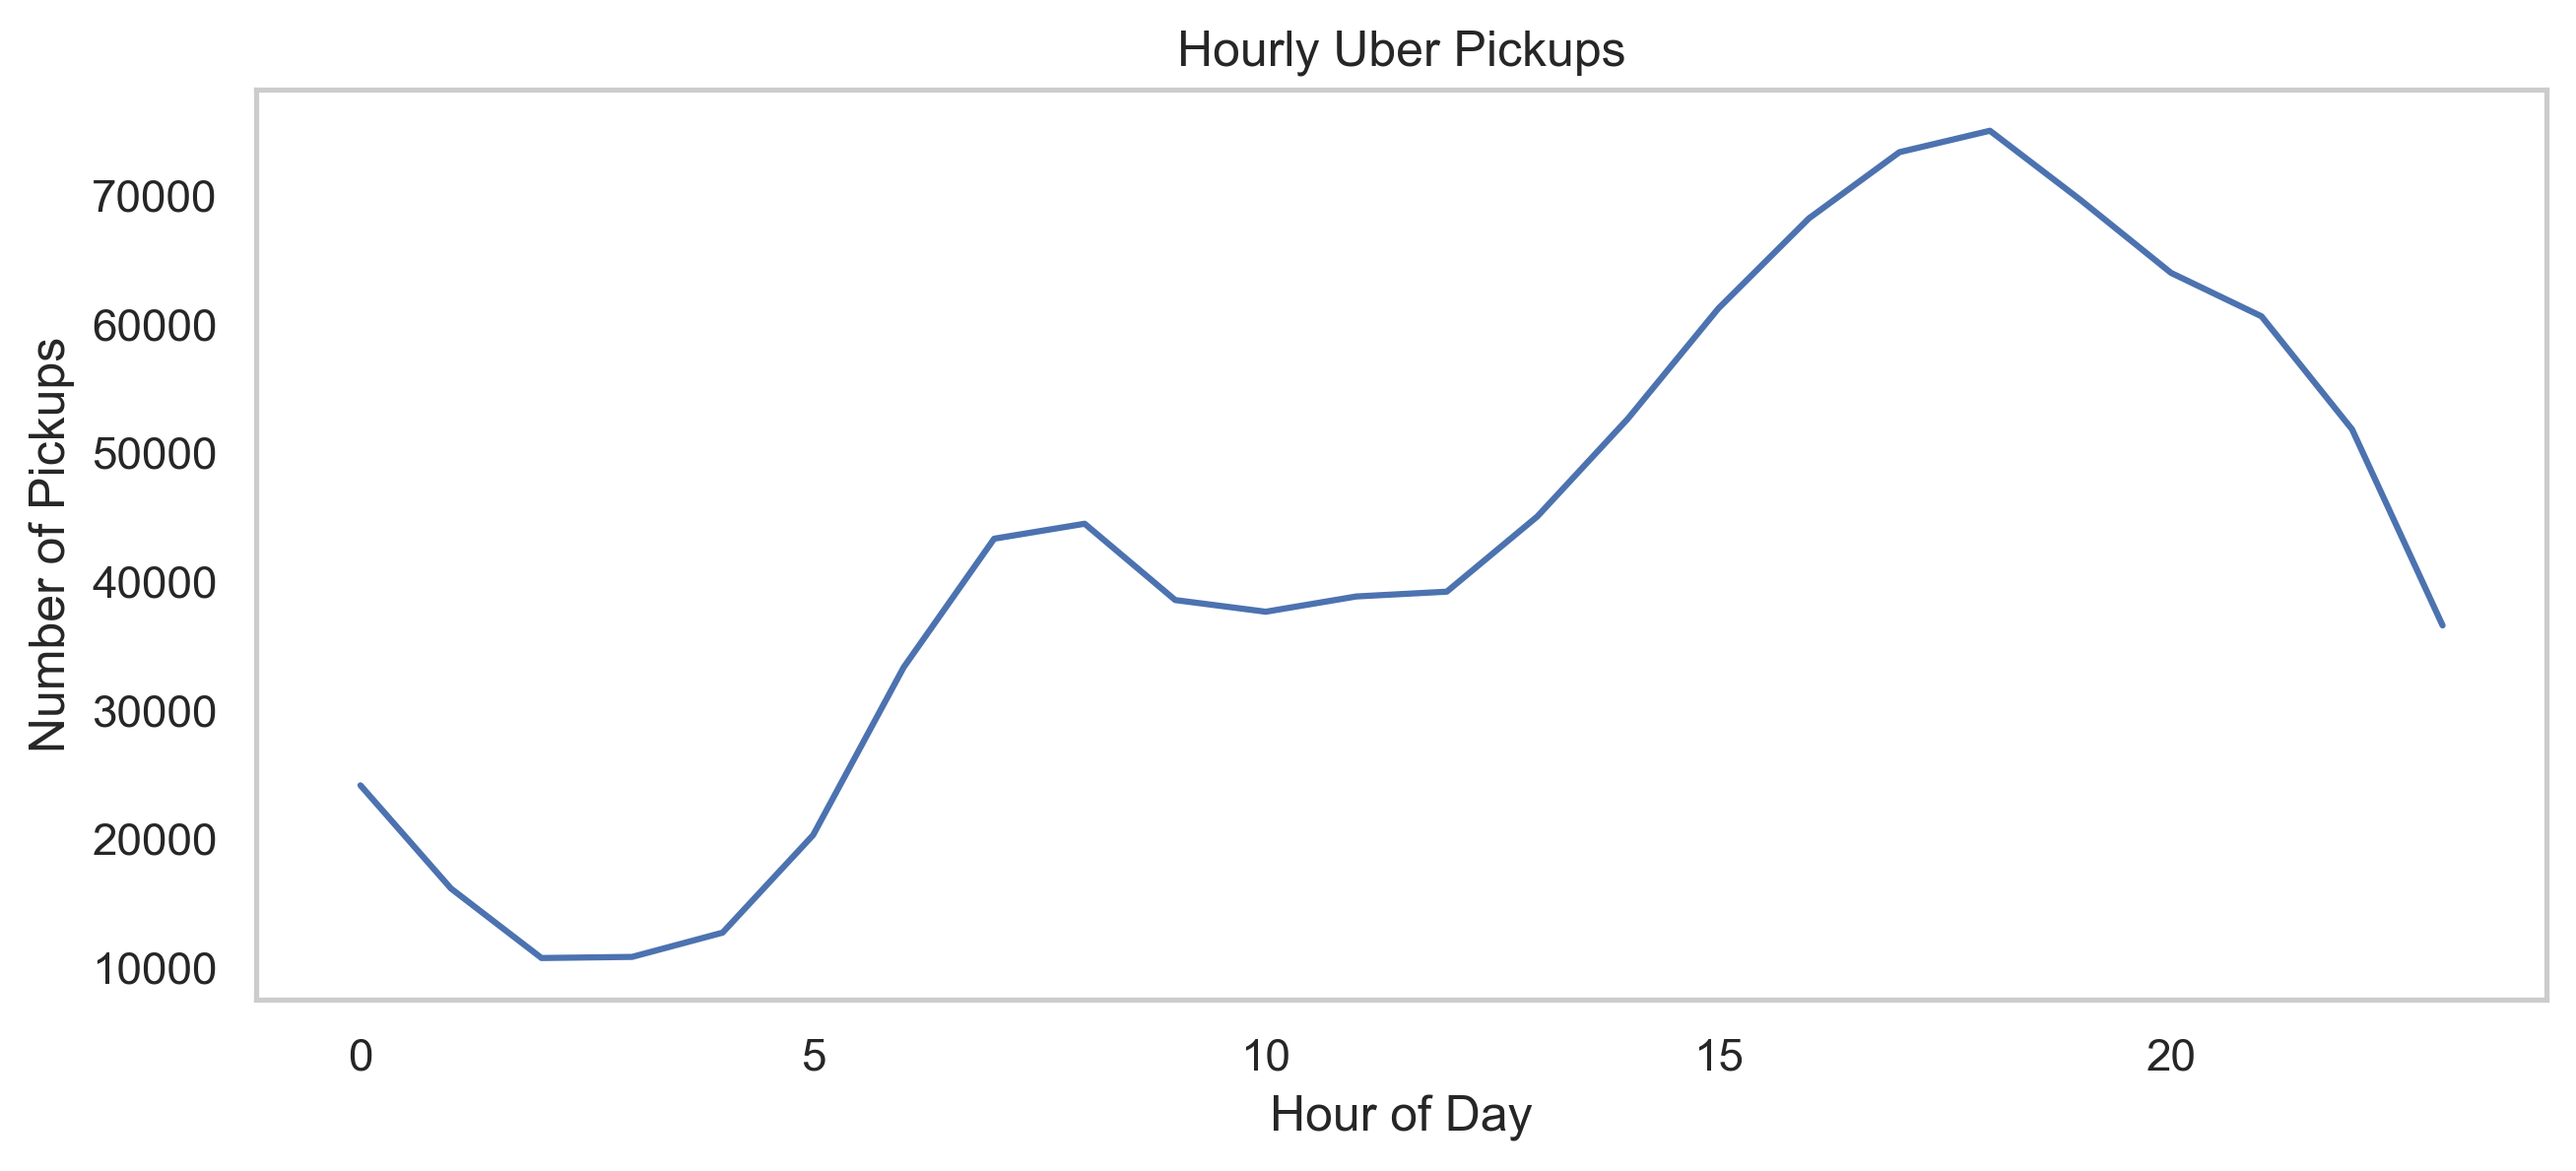

In [15]:
plt.figure(figsize=(10, 4))  
# 출력할 그래프의 크기를 가로 10인치, 세로 4인치로 설정함  
# 시간 순 흐름을 시각화하는 선형 그래프에 적절한 가로 중심 비율을 설정함

df["hour"].value_counts().sort_index().plot(kind="line")  
# 'hour' 컬럼에 대해 값의 빈도수를 계산함  
# 시간대 순으로 정렬하여 자연스러운 시간 흐름을 재구성함  
# 정렬된 결과를 선 그래프 형태로 시각화함  
# x축은 시간대(hour), y축은 해당 시간의 우버 호출 횟수를 나타냄  

plt.title("Hourly Uber Pickups")  
# 그래프 제목을 'Hourly Uber Pickups'로 설정함  
# 시각화된 내용이 시간대별 우버 호출 건수임을 명확히 전달함  

plt.xlabel("Hour of Day")  
# x축 레이블을 'Hour of Day'로 지정함  
# 시간 단위를 기반으로 한 분포임을 나타냄  

plt.ylabel("Number of Pickups")  
# y축 레이블을 'Number of Pickups'로 지정함  
# 각 시간대별 우버 호출 빈도를 명시함  

plt.grid()  
# 그래프에 격자선을 추가함  
# 데이터 추세와 포인트 간의 상대적 높낮이를 쉽게 비교할 수 있도록 시각적 보조선을 제공함  

# -----------------------------------------------

# # 시간대별 탑승 수 집계
# hour_counts = df['hour'].value_counts().sort_index() 
# 시간대별 탑승 수 구한 후 sort_index()를 통해 시간 순서대로 정렬

# # Line Plot 그리기
# plt.figure(figsize=(10,5))
# sns.lineplot(x = hour_counts.index, y = hour_counts.values)

# plt.grid(False)
# plt.title("Hourly Uber Pickups")
# plt.ylabel("Number of Pickups")
# plt.xlabel("Hour of day")
# plt.show()

## 2. 비교 시각화 – 요일별 탑승 수 (Bar Plot)

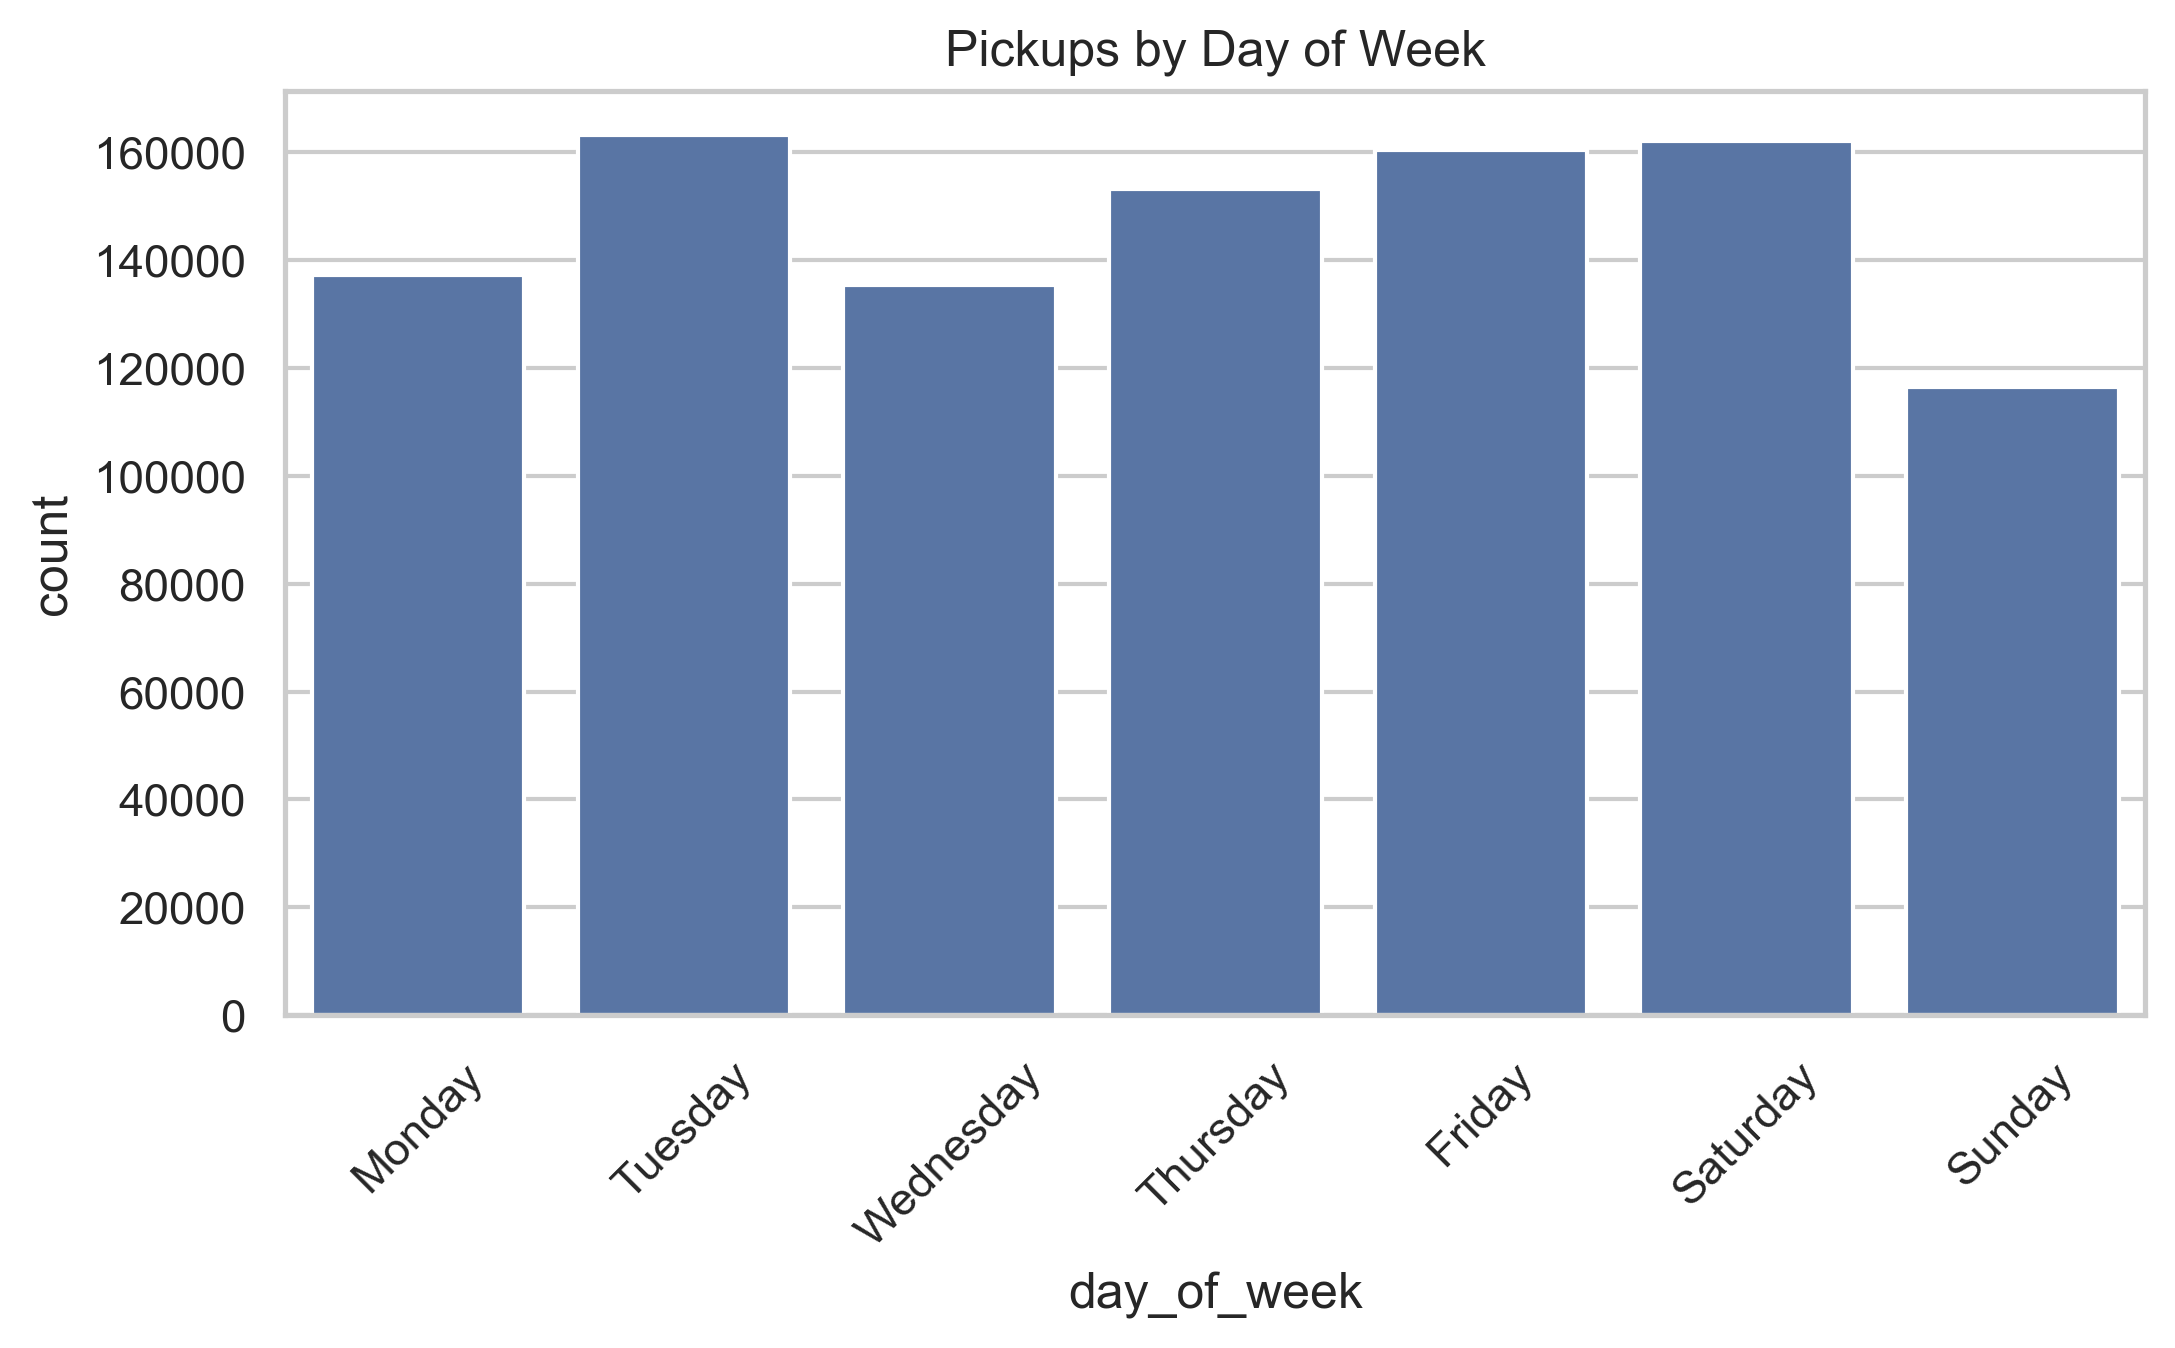

In [16]:
plt.figure(figsize=(8, 4))
# 그래프의 전체 크기를 가로 8인치, 세로 4인치로 설정함  
# 주간 단위의 요일 분포를 시각화할 때 적절한 가로 중심 비율을 설정함  

sns.countplot(
    x="day_of_week",          # x축에 'day_of_week' 컬럼의 값을 카테고리로 설정함  
    data=df,                  # 입력 데이터로 DataFrame df를 사용함  
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    # 요일 순서가 무작위로 나타나는 것을 방지하고, 실제 주간 흐름대로 정렬함  
    # 명시적 순서를 지정하여 x축이 월요일에서 일요일 순서로 고정되도록 설정함  
)
# seaborn의 countplot을 사용하여 각 요일별 데이터 빈도수를 막대그래프로 시각화함  
# 각 요일에 해당하는 우버 호출 수를 막대의 높이로 표현함  
# 범주형 변수의 빈도 분포를 빠르게 파악할 수 있는 기본적인 도구임  

plt.title("Pickups by Day of Week")
# 그래프의 제목을 지정함  
# 시각화된 내용이 요일별 우버 호출 건수임을 명확히 전달함  

plt.xticks(rotation=45)
# x축 레이블인 요일 이름들을 45도 회전시켜서 글자가 겹치지 않도록 함  
# 긴 텍스트로 인한 시각적 충돌을 방지하고 가독성을 향상시킴  

plt.show()
# 설정한 모든 시각화 요소를 포함한 그래프를 출력함  
# Jupyter 환경이나 GUI 기반 인터프리터에서 화면에 실제 결과를 시각적으로 렌더링함  

# -----------------------------------------------

# # 요일 순서를 따르기 위해 groupby + reindex 사용
# day_order = ['Monday', "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
#     # 요일별 탑승 수 집계
# day_counts = df.groupby("day_of_week").size().reindex(day_order)

# # Bar plot 그리기 
# plt.figure(figsize=(10, 5))
# sns.barplot(x = day_counts.index, y = day_counts.values)

# plt.grid(axis='y')
# plt.title("Pickups by Day of Week")
# plt.xlabel("day_of_week")
# plt.ylabel("count")
# plt.xticks(rotation = 45) # X 축 레이블 회전
# plt.show()


## 3. 관계 시각화 – 요일 vs 시간별 탑승 수 히트맵 (Heatmap)

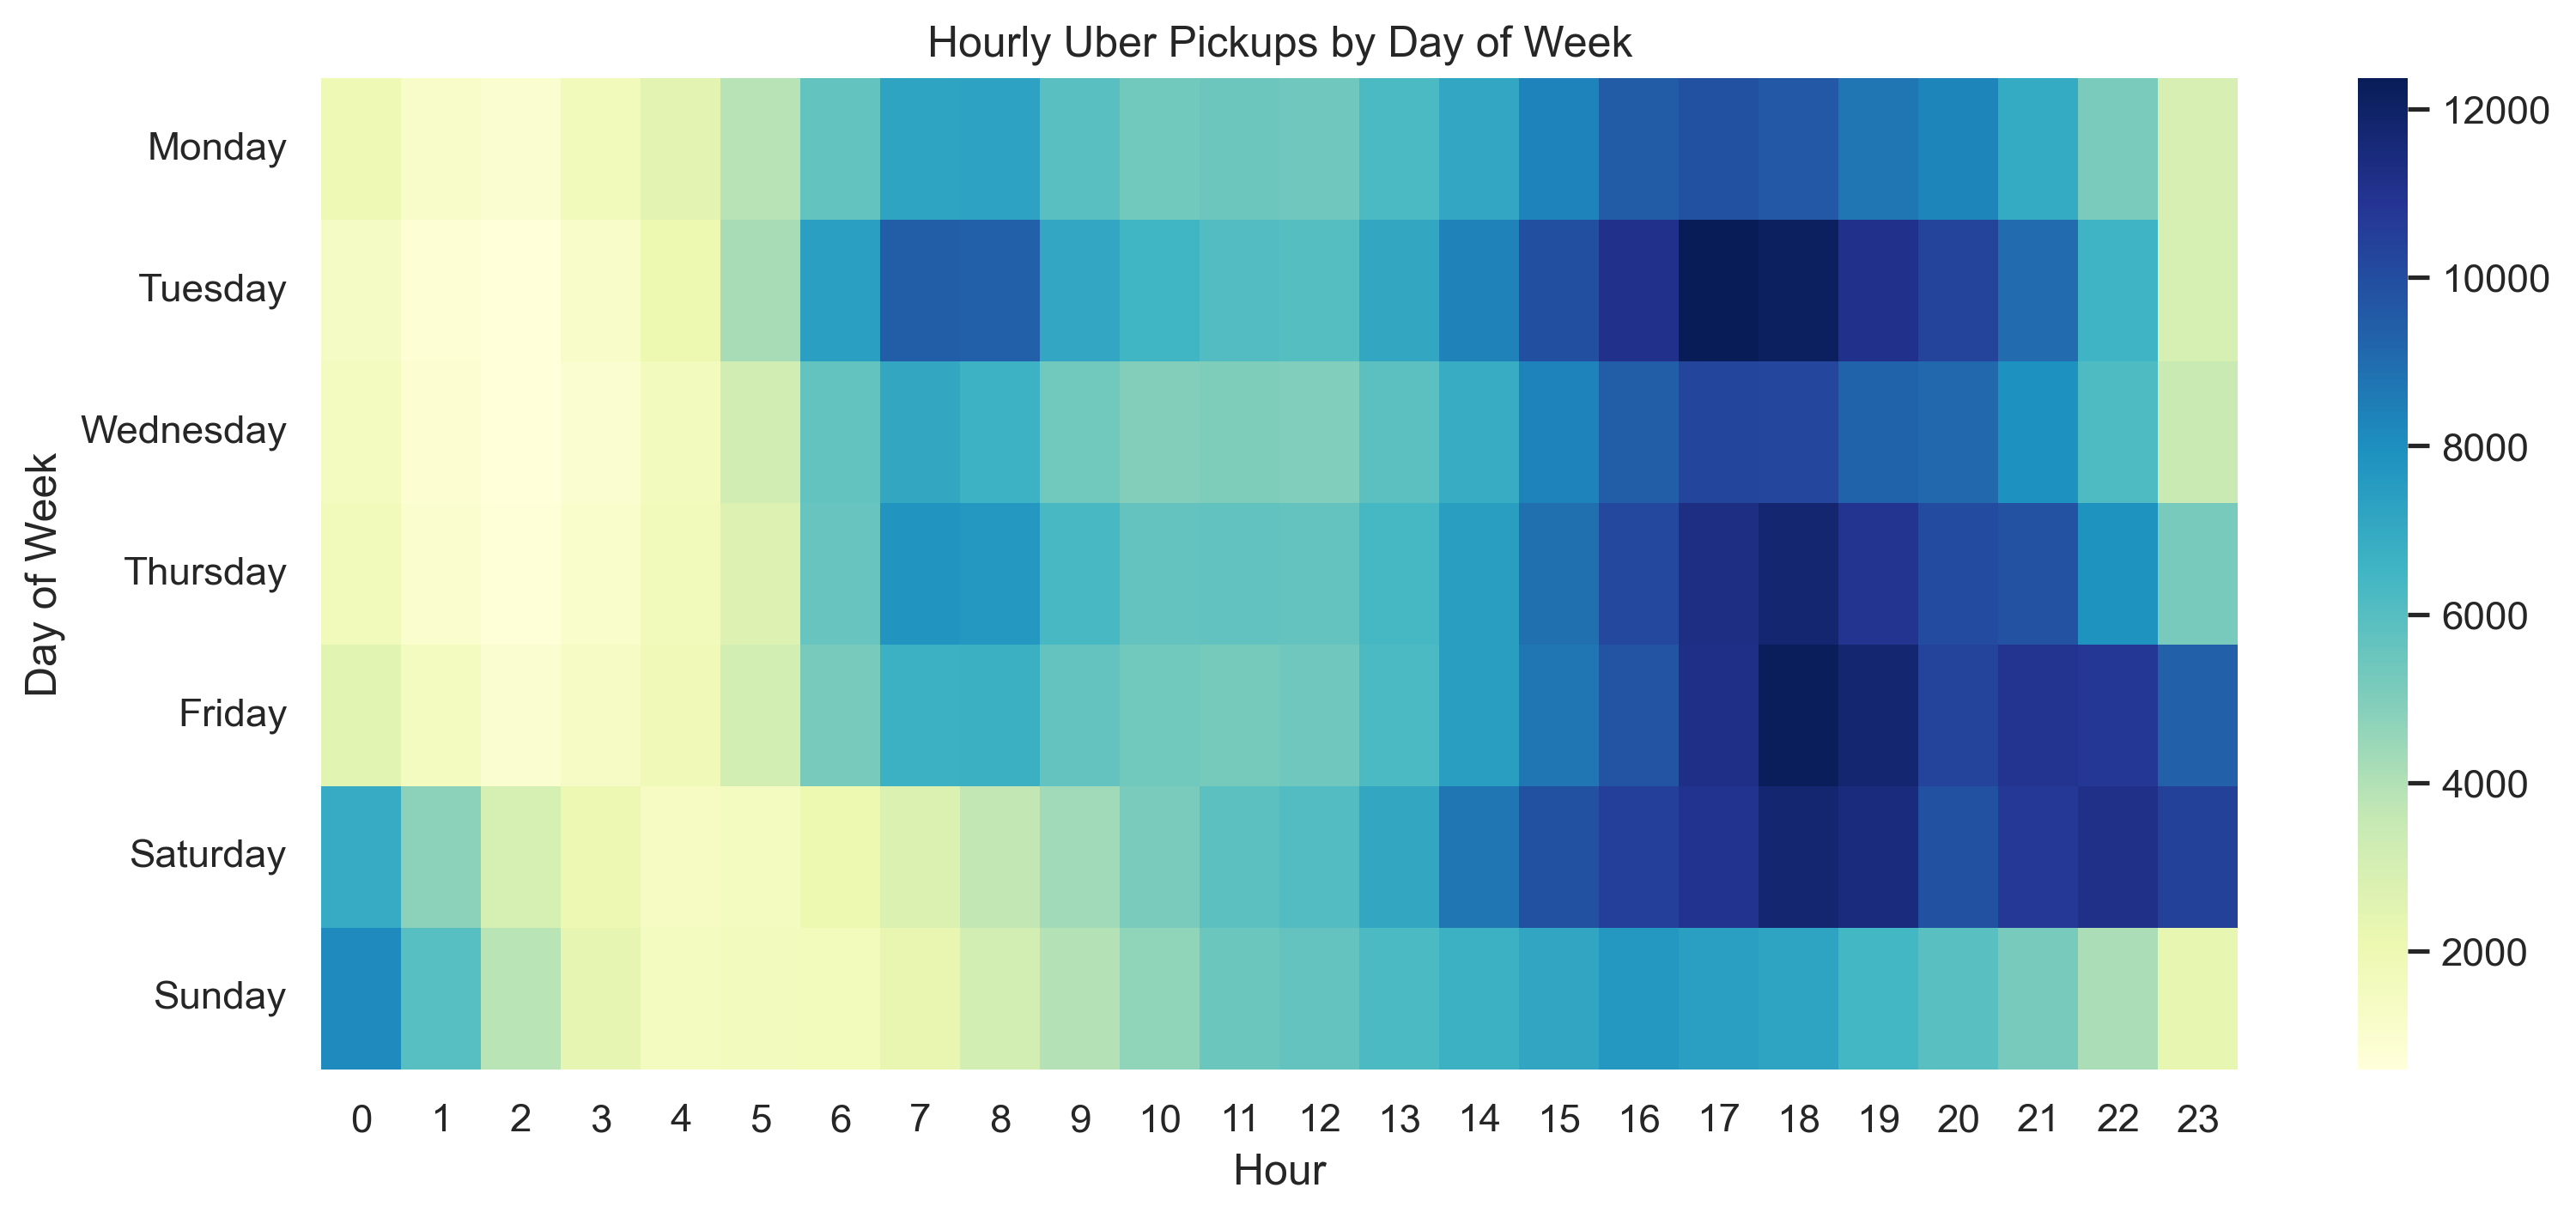

In [ ]:
pivot = df.pivot_table(
    index="day_of_week",        # 행 인덱스를 'day_of_week'으로 설정함
    columns="hour",             # 열 인덱스를 'hour'으로 설정함
    values="Date/Time",         # 집계 대상 값을 'Date/Time'으로 지정함
    aggfunc="count"             # 집계 방식은 'count'로 설정하여 빈도수를 계산함
)
# 요일(day_of_week)과 시간(hour) 기준으로 우버 호출 횟수를 교차표 형태로 요약한 피벗 테이블 생성함
# 결과는 각 요일의 각 시간대별 호출 건수를 나타내는 2차원 표 형태임

ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# 시각적 해석 순서를 보장하기 위해 요일의 순서를 명시적으로 정의함

pivot = pivot.reindex(ordered_days)
# 생성된 피벗 테이블의 행 순서를 실제 요일 순서대로 재정렬함
# 자동 정렬로 인해 요일이 알파벳순으로 배열되는 것을 방지함

plt.figure(figsize=(12, 5))
# 전체 그래프 크기를 가로 12인치, 세로 5인치로 설정함
# 시간(hour) 축이 길기 때문에 넓은 가로 공간 확보가 필요함

sns.heatmap(pivot, cmap="YlGnBu")
# seaborn의 heatmap을 사용하여 피벗 테이블을 색상으로 시각화함
# 값이 클수록 진한 파란색, 작을수록 연노랑으로 표시되는 색상 맵(YlGnBu)을 적용함
# 각 셀은 특정 요일의 특정 시간대의 우버 호출량을 색으로 표현함

plt.title("Hourly Uber Pickups by Day of Week")
# 전체 그래프의 제목을 설정함
# 이 그래프가 요일과 시간대에 따른 우버 호출 분포를 나타냄을 설명함

plt.xlabel("Hour")
# x축 레이블을 'Hour'로 지정함
# 열 인덱스로 사용된 시간(hour) 값을 의미함

plt.ylabel("Day of Week")
# y축 레이블을 'Day of Week'로 지정함
# 행 인덱스로 사용된 요일(day_of_week) 값을 의미함

plt.show()
# 모든 구성 요소가 설정된 heatmap을 출력함

# -----------------------------------------------

# # pivot_table()로 요일-시간 조합별 탑승 수 만들기
# heatmap_data = df.pivot_table(
#     index="day_of_week",   # 행 기준: 요일
#     columns="hour",        # 열 기준: 시간 (0~23)
#     values="Date/Time",    # 값을 카운트할 대상
#     aggfunc="count"        # 값의 개수를 집계
# ).reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

# # ✅ 1. df.pivot_table(...)
# # 📌 목적:
# # DataFrame을 요일 × 시간 형태의 2차원 테이블로 변환.
# # 각 교차점에 있는 값은 해당 요일-시간에 발생한 우버 픽업 수(count).

# # ✅ 2. .reindex([...])
# # 📌 목적:
# # 요일 순서를 명시적으로 지정해서, pivot_table()이 임의의 순서로 행을 배치하지 않도록 함.

# # Heatmap 그리기
# plt.figure(figsize=(20,10))

# ax = sns.heatmap(
#     heatmap_data, 
#     cmap="YlGnBu", 
#     cbar_kws={'label': 'Number of Pickups'}
# )  # colorbar 라벨 지정

# plt.title("Heatmap of Uber Pickups by Day and Hour", fontsize=20)
# plt.xlabel("Hour of Day", fontsize=20)
# plt.xticks(fontsize=15)  # X축(시간) 레이블 크기 키우기
# plt.ylabel("Day of Week", fontsize=20)
# plt.yticks(fontsize=15, rotation=0)  # Y축(요일) 레이블 크기 키우기 + 회전 (0 = 가로)

# # 오른쪽 색상바(colorbar)의 틱 레이블 폰트 크기 조정
# cbar = ax.collections[0].colorbar   # heatmap의 colorbar 접근
# cbar.ax.tick_params(labelsize=15)     # 색상바 틱 레이블 폰트 크기 조정

# plt.show()

## 4. 패턴 시각화 – 요일별 평균 탑승 수 방사형 차트 (Radar Chart)

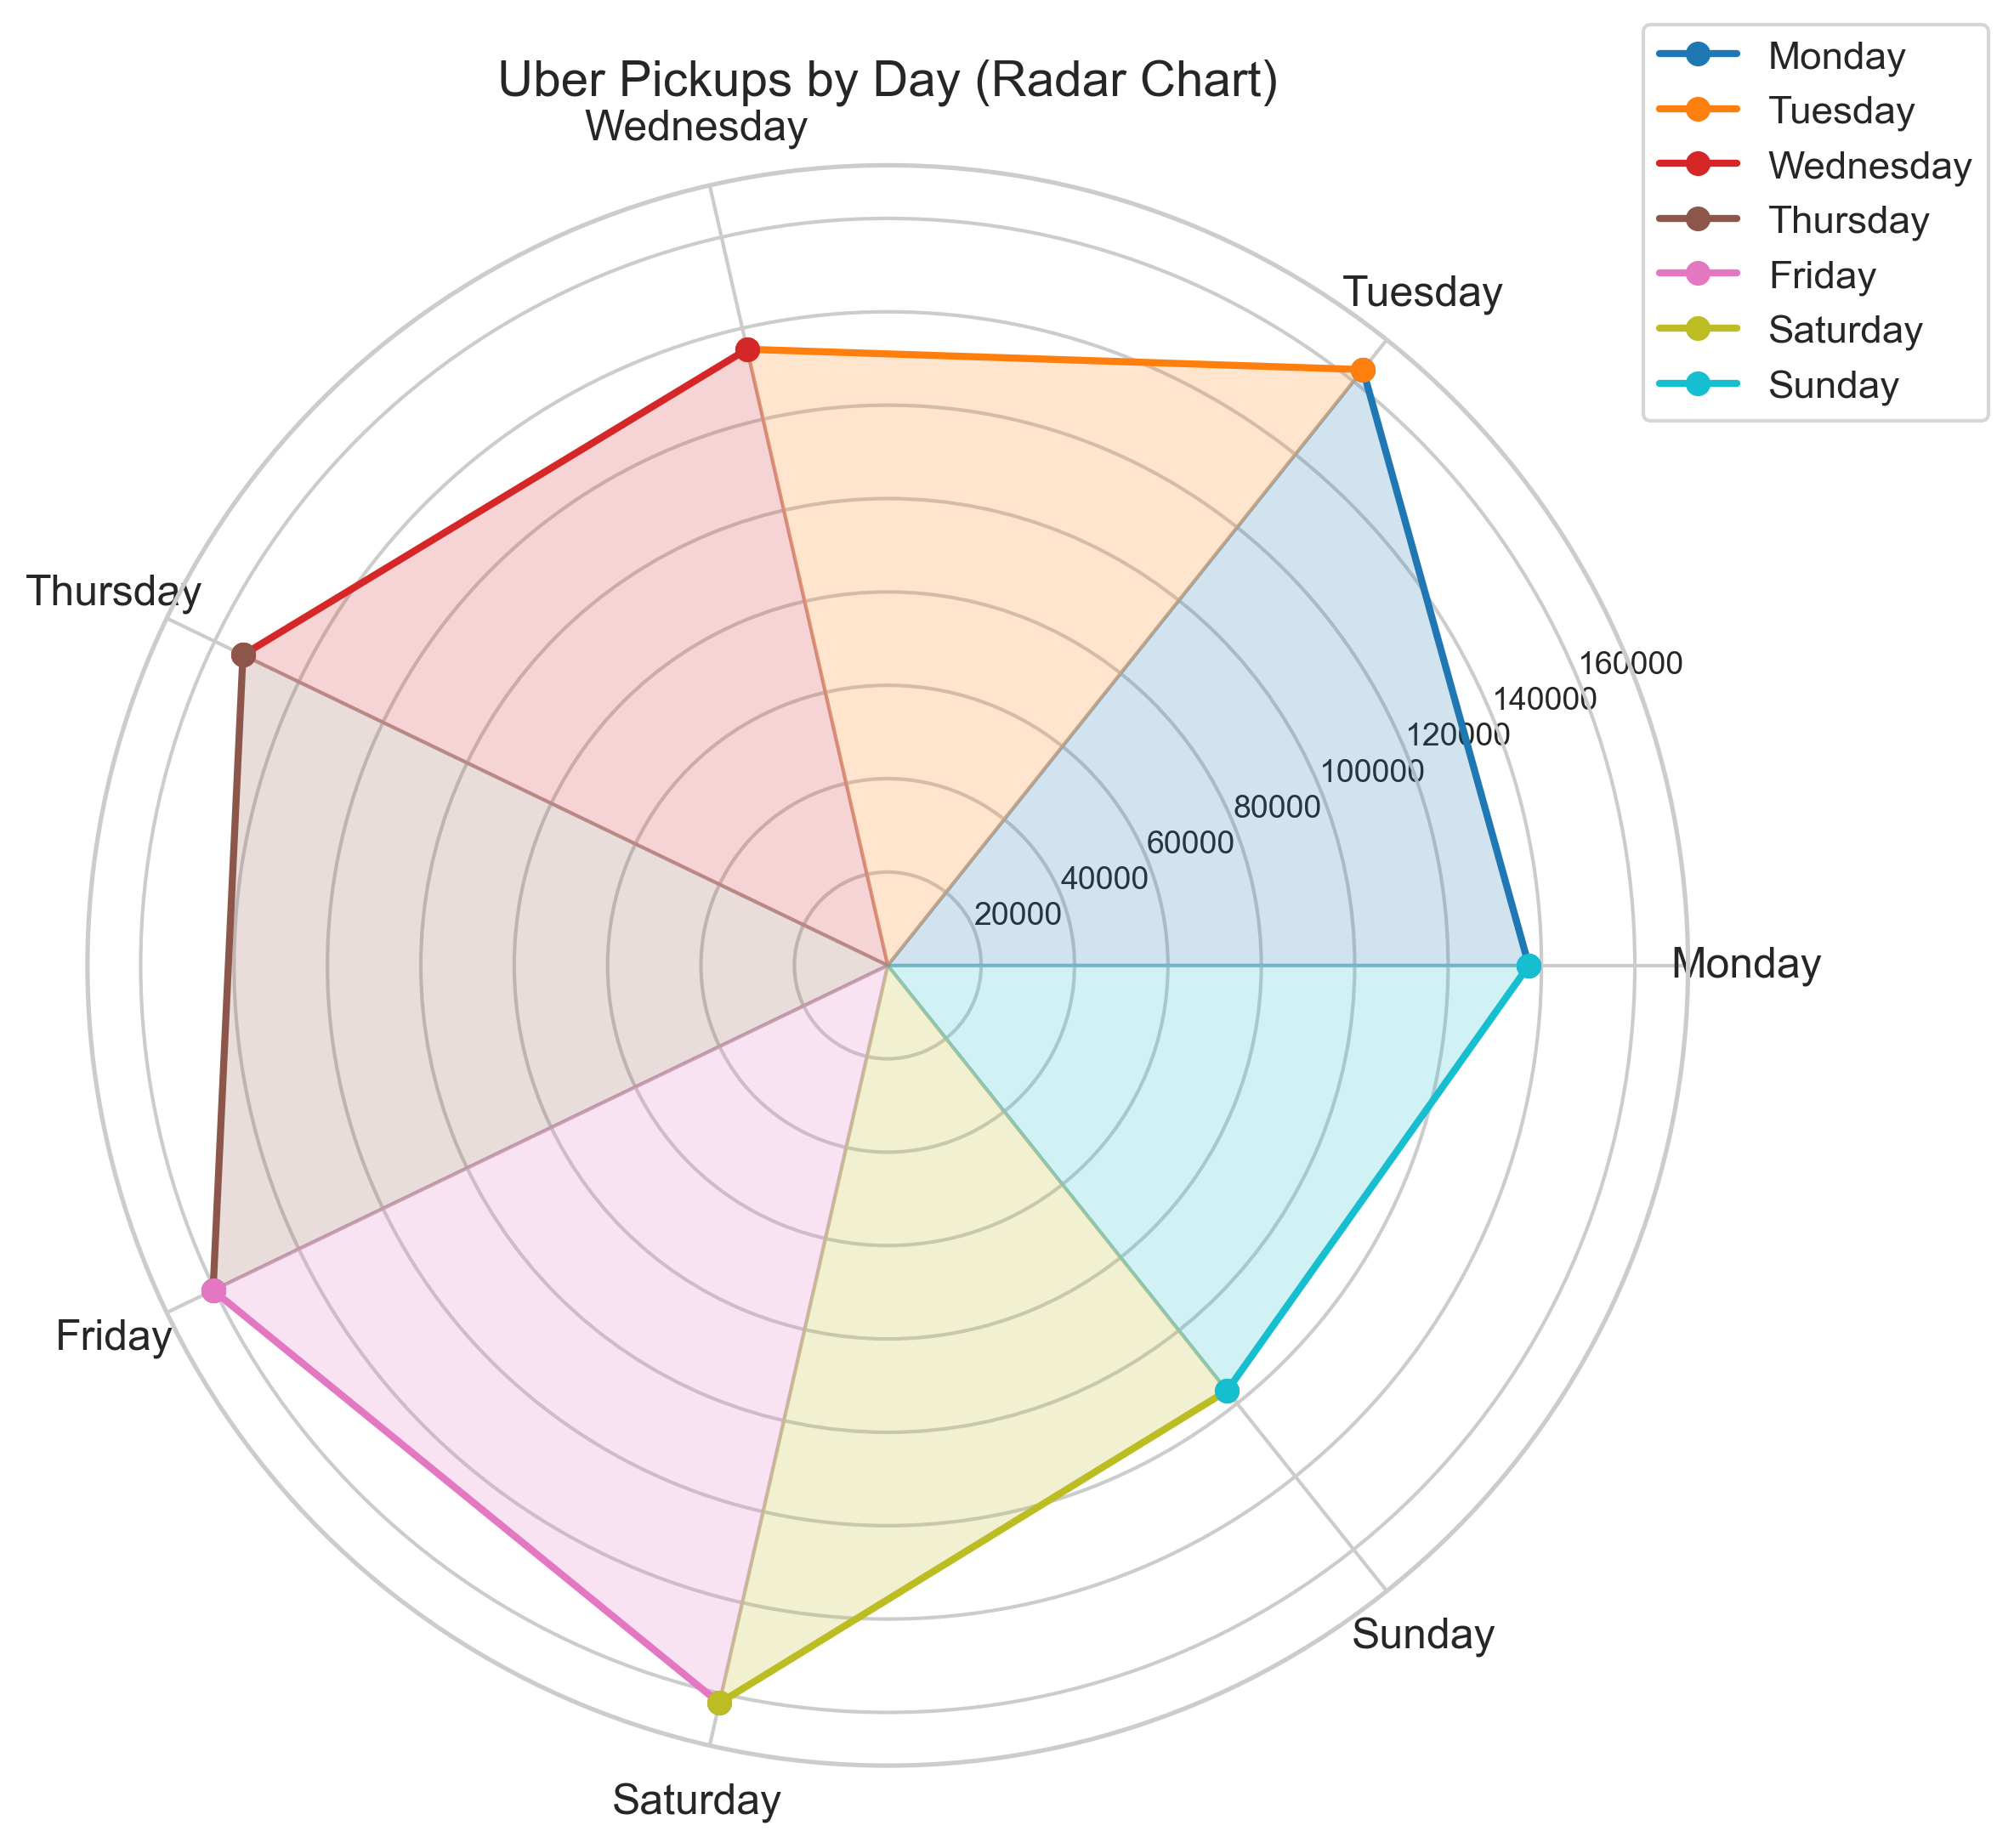

In [21]:
ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# 시각적 해석 순서를 보장하기 위해 요일의 순서를 명시적으로 정의함

day_avg = df["day_of_week"].value_counts().reindex(ordered_days)
# 'day_of_week' 컬럼에서 요일별 우버 호출 수를 집계함
# value_counts()는 각 요일의 빈도수를 반환함
# 요일 순서가 알파벳 기준으로 정렬되어 있기 때문에, reindex()를 통해 실제 요일 순서로 재정렬함
# 결과는 ordered_days 순서대로 정렬된 Series 형태의 요일별 호출 수임

values = day_avg.values
# 요일별 호출 수 Series에서 값 부분만 NumPy 배열로 추출함
# 각 요일에 해당하는 반지름 값으로 사용됨

labels = day_avg.index.tolist()
# 요일 이름 인덱스를 리스트로 변환함
# 각 레이더 축의 라벨(방향 이름)로 사용됨

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
# 0부터 2π 라디안(360도)까지 전체 원을 len(labels) 개수만큼 균등하게 나눈 각도를 생성함
# 각 값은 라디안 단위이며, 레이더 차트에서 각 축(요일)의 위치를 결정함
# endpoint=False를 설정하여 마지막 각도인 2π는 포함하지 않음
# 마지막 값을 생략함으로써 처음 각도와 동일한 위치에 중복되는 축이 생기는 것을 방지함
# 예: 7개의 요일이 있다면 각 요일은 0, 2π/7, 4π/7, ..., (6×2π/7) 라디안 위치에 배치됨
# tolist()를 사용하여 numpy 배열을 일반 파이썬 리스트로 변환함
# 이 리스트는 이후 점 연결, 면 채우기 등에 각도 기준으로 활용됨

values = np.concatenate((values, [values[0]]))
# 기존 values 배열의 첫 번째 값을 다시 배열 끝에 추가하여 폐곡선 형태를 구성함
# 레이더 차트에서는 마지막 점이 다시 처음 점으로 연결되어야 도형이 닫힘
# 이 처리가 없으면 마지막 점과 처음 점 사이에 선이 연결되지 않아 차트가 열려 있음
# np.concatenate는 두 배열을 하나로 이어붙이는 함수이며, 이 경우 [values[0]]을 한 요소짜리 배열로 추가함
# 결과적으로 len(values)는 len(labels) + 1이 되며, len(angles)도 같은 크기로 맞춰줘야 함

angles += [angles[0]]
# 각도 리스트에도 첫 번째 각도를 끝에 추가하여 도형이 원형으로 닫히도록 설정함
# len(values) == len(angles)가 되어야 그릴 수 있음

colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
# matplotlib의 'tab10' 컬러 맵에서 10가지 색상을 균등 간격으로 추출함
# 각 요일마다 고유한 색상을 할당하여 시각적 구분을 강화함

fig, ax = plt.subplots(subplot_kw={'polar': True}, figsize=(8, 8))
# polar 좌표계(방사형 차트)를 설정하기 위해 subplot_kw에 polar=True 옵션을 부여함
# figsize=(8, 8)로 설정하여 원형 차트가 왜곡되지 않도록 정사각형 비율로 출력함
# ax는 이후 차트 요소를 추가할 축 객체로 사용됨

for i in range(len(labels)):
    ax.plot(
        [angles[i], angles[i+1]],
        # 레이더 차트에서 현재 요일(i)과 다음 요일(i+1)의 각도를 연결선의 시작점과 끝점으로 사용함
        [values[i], values[i+1]],
        # 각 각도에서의 반지름 값(우버 호출 수)을 y좌표로 사용함
        # 두 값 사이를 연결하여 하나의 윤곽선(segment)을 형성함
        marker='o',
        # 각 점마다 원형 마커를 표시하여 데이터 포인트를 시각적으로 강조함
        color=colors[i],
        # 요일별로 미리 지정된 색상을 선의 색상으로 설정함
        linewidth=2,
        # 선의 두께를 2로 지정하여 시각적 명확성을 확보함
        label=labels[i]
        # 범례에 사용될 라벨을 현재 요일 이름으로 지정함
    )
    # 현재 요일(i)에서 다음 요일(i+1)로 이어지는 외곽선을 그림
    # polar 좌표계에서 (각도, 반지름)의 형태로 선을 연결함
    # 마커와 색상을 통해 각 요일을 식별 가능하게 구성함

    ax.fill(
        [angles[i], angles[i+1], angles[i+1], angles[i]],
        # 사다리꼴 형태를 구성하기 위한 네 꼭짓점의 각도 좌표를 정의함
        # 아래쪽 두 점은 원점(반지름 0), 위쪽 두 점은 해당 요일의 값으로 설정함
        [0, 0, values[i+1], values[i]],
        # 반지름 방향 값으로 y좌표를 설정함
        # 하단은 0으로 고정하고 상단은 요일별 픽업 수 값으로 채움
        color=colors[i],
        # 동일한 요일 색상을 면 색상으로 적용하여 시각적 일관성을 유지함
        alpha=0.2
        # 면을 20% 투명도로 채워 윤곽선을 가리지 않으면서 면적 차이를 표현함
    )
    # 각 요일 간 면적을 사다리꼴 형태로 채우는 시각화 단계임
    # 면적 크기가 요일 간 상대적 픽업량 차이를 직관적으로 보여줌

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
# 각 방사형 축(방향선)에 해당하는 각도를 degree(도 단위)로 변환하여 라벨을 설정함
# angles[:-1]는 중복된 마지막 원소를 제외한 각도 리스트임
# 요일별 이름을 대응 각도 위치에 출력하며, 폰트 크기를 12로 지정함

ax.tick_params(axis='y', labelsize=9)
# y축(반지름 방향)의 눈금(label)에 대한 글자 크기를 9로 설정함

for label in ax.get_yaxis().get_ticklabels():
    label.set_rotation(0)
    label.set_fontsize(9)
# 반지름 눈금의 라벨 객체들을 순회하며 회전 각도는 0도(수평)으로 설정함
# 눈금의 글꼴 크기도 9로 통일하여 전체 가독성을 유지함

plt.title("Uber Pickups by Day (Radar Chart)", fontsize=14, pad=20)
# 그래프 제목을 설정함
# 제목의 폰트 크기를 14로 지정하고, 상단 여백을 pad=20으로 확보함
# 그래프 상단에 제목이 떨어져 보이도록 간격 조정함

plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
# 범례를 오른쪽 위 바깥 영역에 위치시킴
# bbox_to_anchor를 통해 범례 위치를 정확하게 조정함
# 각 요일에 해당하는 색상과 선의 의미를 식별할 수 있도록 구성함

plt.tight_layout()
# 전체 플롯 구성 요소들이 겹치지 않도록 자동으로 레이아웃을 정리함

plt.show()
# 구성된 레이더 차트를 시각적으로 출력함
# 노트북, GUI 환경에서 최종 그래프 결과를 화면에 렌더링함


## 5. 분포 시각화 - 시간대별 분포 (히스토그램)

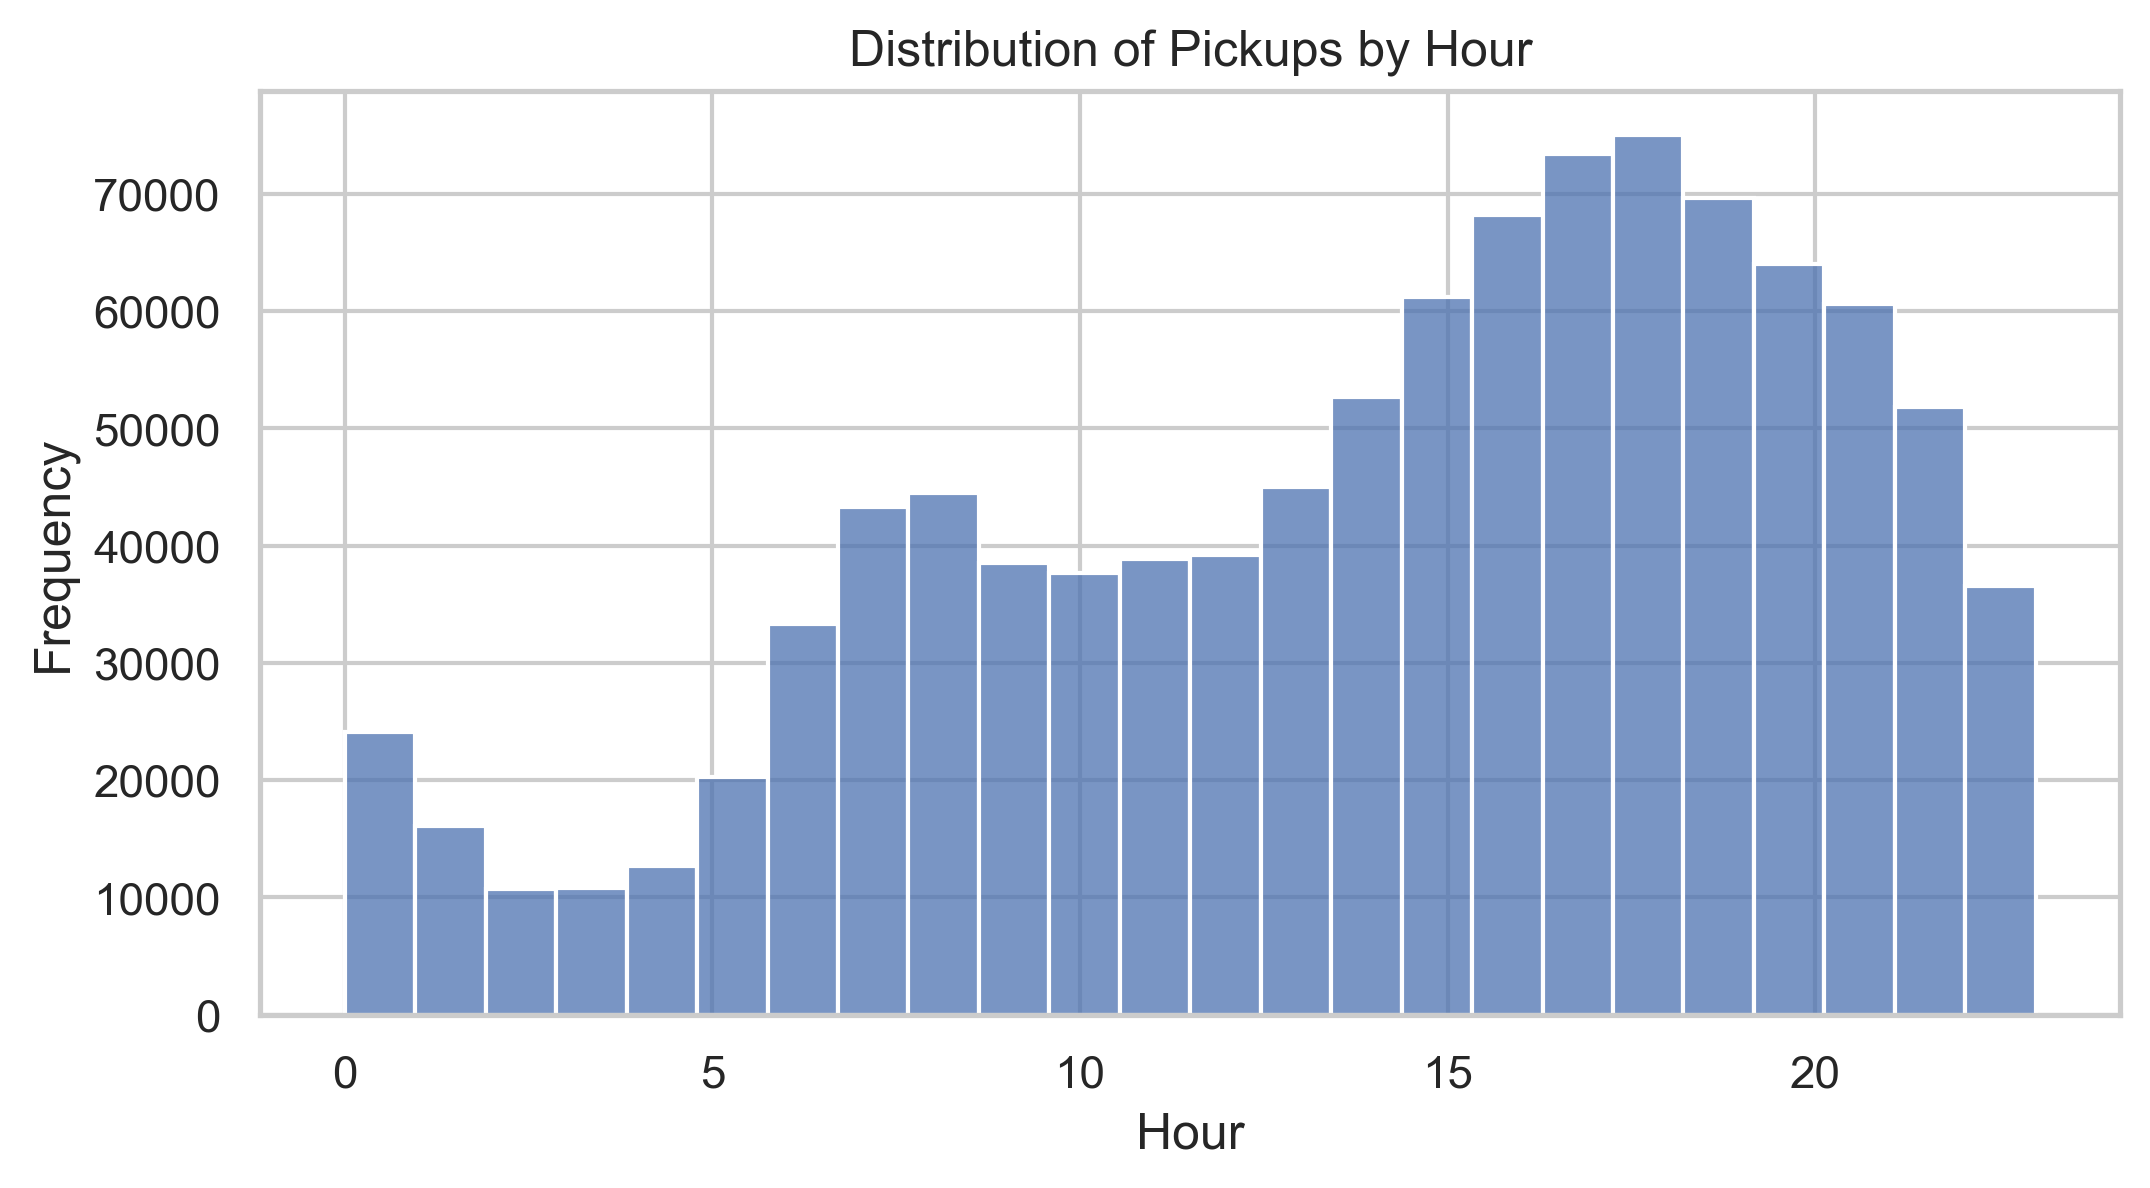

In [22]:
plt.figure(figsize=(8, 4))
# 출력할 그래프의 전체 크기를 가로 8인치, 세로 4인치로 설정함  
# 24시간 기준 분포를 가로 방향으로 충분히 표현할 수 있도록 비율을 조정함  

sns.histplot(df["hour"], bins=24, kde=False)
# 'hour' 컬럼을 기반으로 히스토그램을 생성함  
# bins=24를 통해 0시부터 23시까지 총 24개의 시간 구간으로 나눔  
# 각 막대는 해당 시간에 발생한 우버 호출 수(빈도)를 나타냄  
# kde=False 설정으로 커널 밀도 추정 곡선을 제외하고 막대그래프만 시각화함  

plt.title("Distribution of Pickups by Hour")
# 그래프 상단에 제목을 'Distribution of Pickups by Hour'로 설정함  
# 시각화된 데이터가 시간대별 우버 호출 분포임을 명확하게 전달함  

plt.xlabel("Hour")
# x축 레이블을 'Hour'로 설정함  
# 수평축에 표시된 값들이 24시간 기준의 시간 단위임을 설명함  

plt.ylabel("Frequency")
# y축 레이블을 'Frequency'로 설정함  
# 각 막대의 높이가 해당 시간에 발생한 호출 빈도임을 나타냄  

plt.show()
# 구성된 히스토그램을 화면에 출력함  
# 시각적 분석을 위해 그래프를 실제 렌더링하여 사용자에게 표시함  


## 6. 관계 시각화 - 위도 vs 경도 산점도

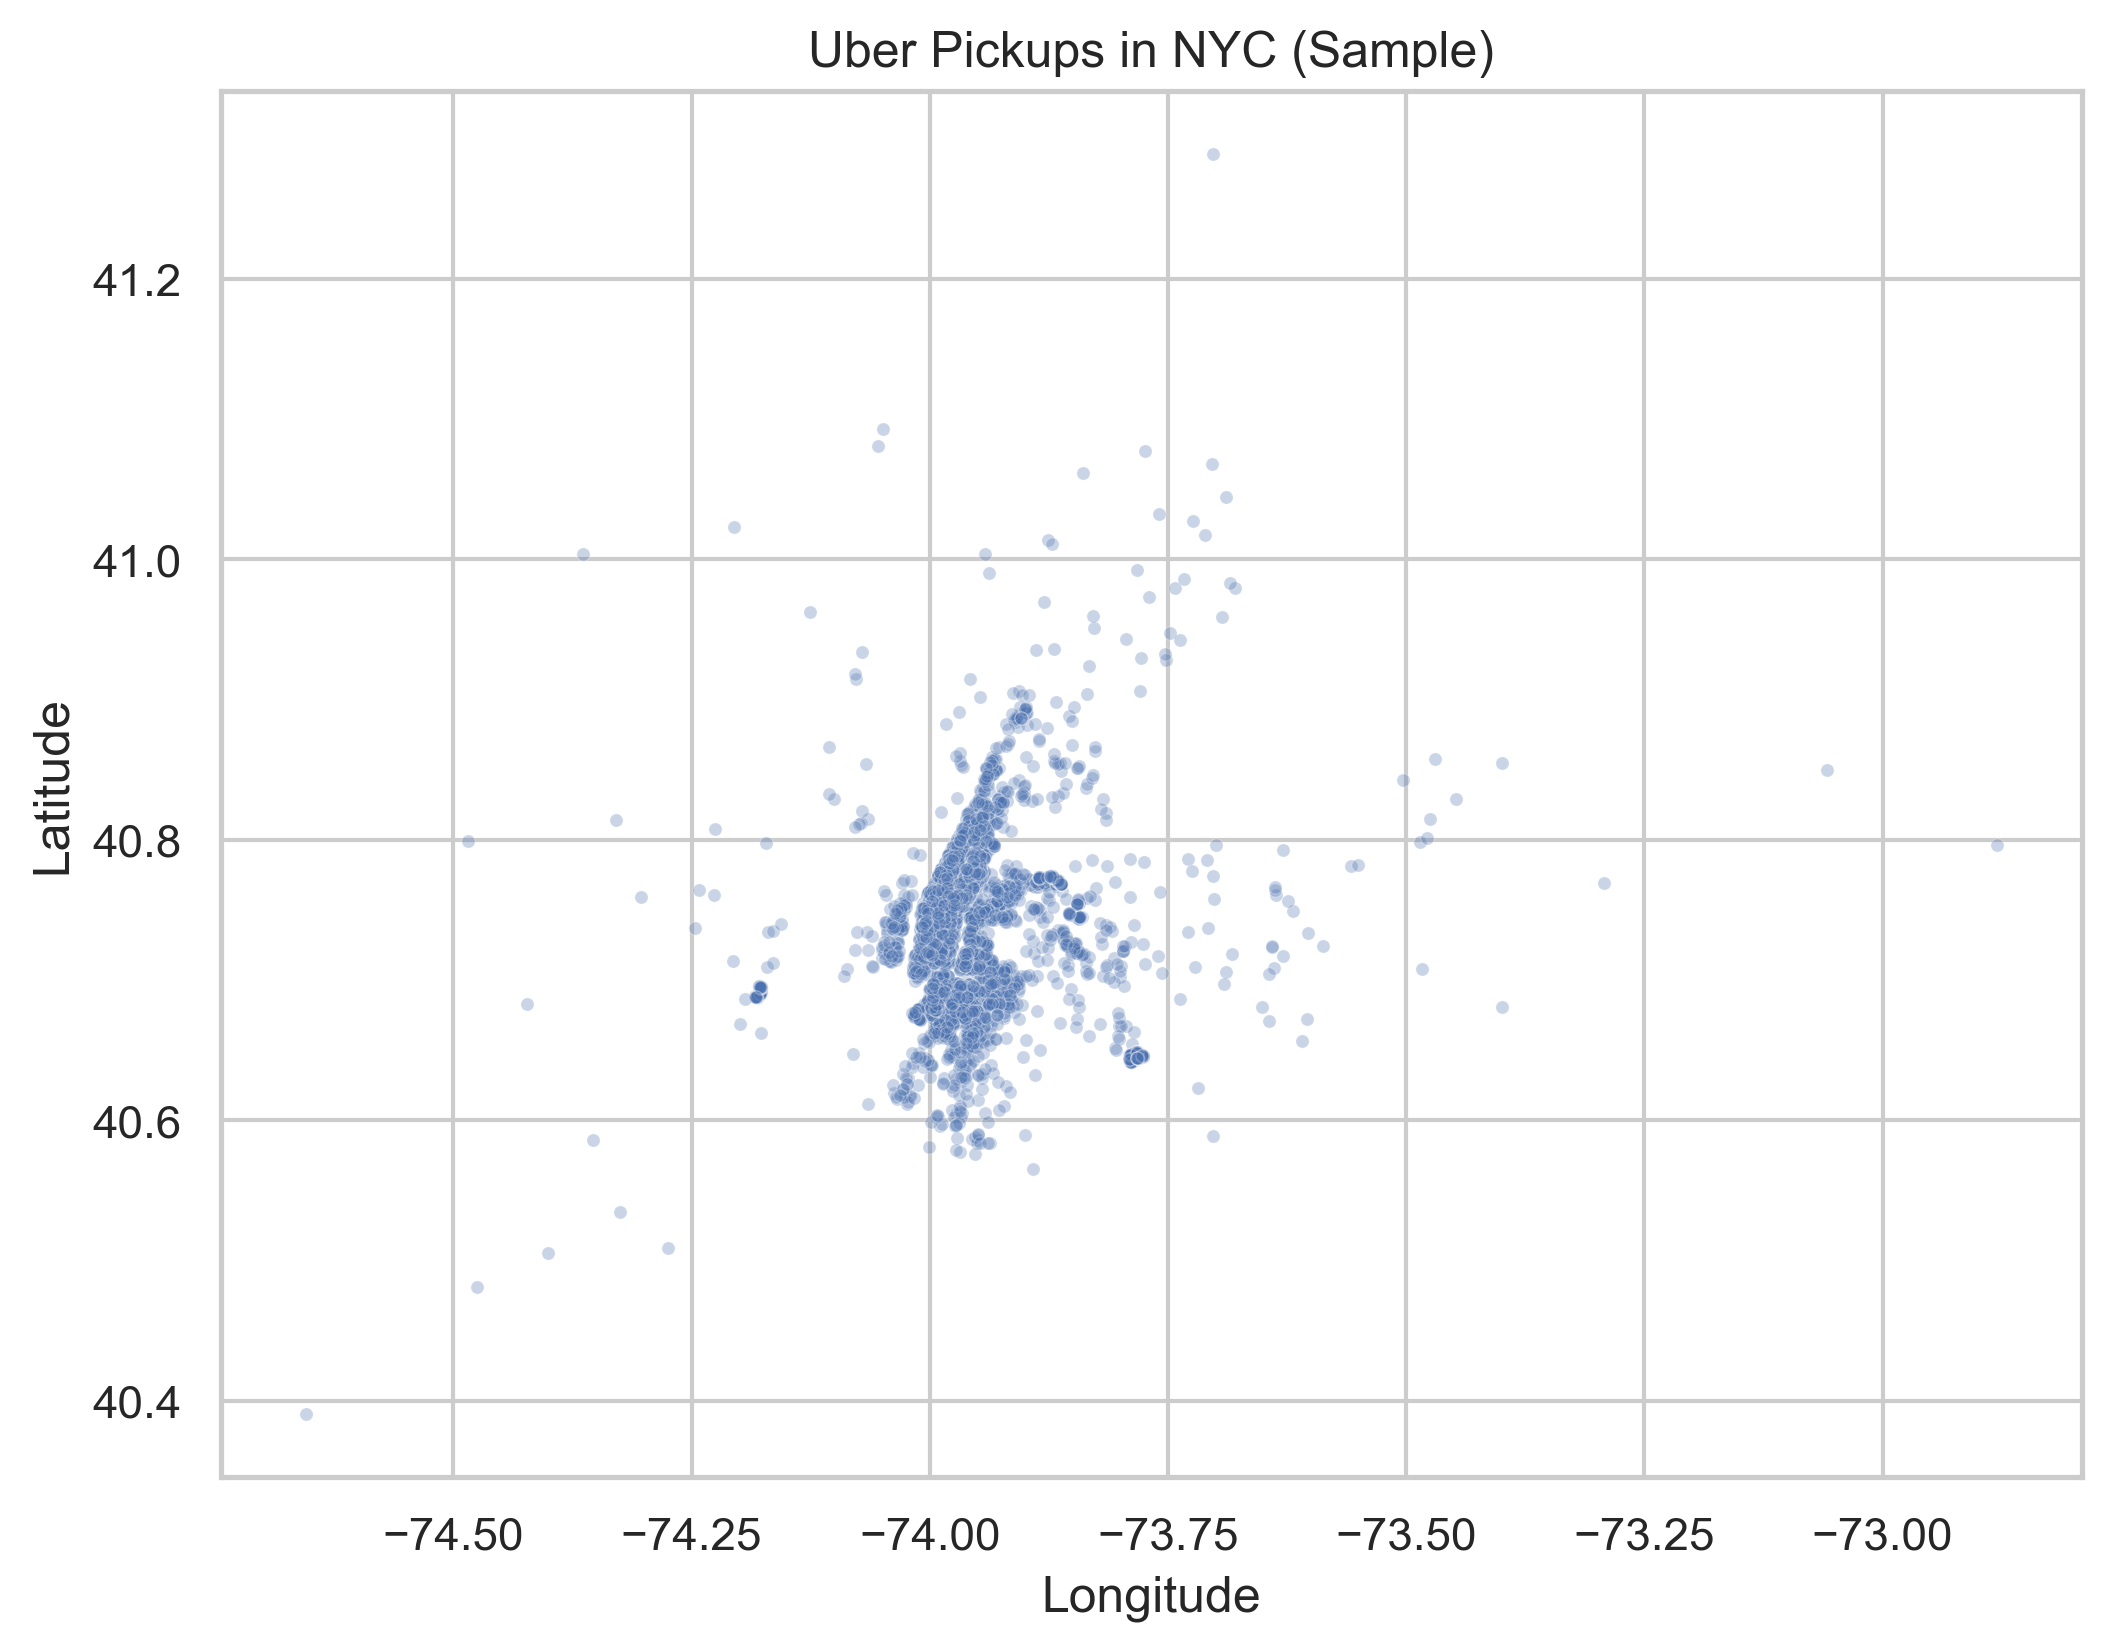

In [25]:
sample_df = df.sample(10000)
# 전체 데이터프레임(df)에서 임의로 10,000개의 행을 무작위로 추출하여 샘플 데이터 생성함  
# 대용량 데이터의 시각화 성능을 개선하고, 해석 가능한 수준으로 시각적 밀도를 조절하기 위함  

plt.figure(figsize=(8, 6))
# 출력할 그래프의 크기를 가로 8인치, 세로 6인치로 설정함  
# 지리 좌표(위도·경도)를 시각화하는 데 있어 충분한 비율과 해상도를 확보함  

sns.scatterplot(
    x="Lon",
    # x축에 경도(Lon) 값을 설정함  
    # 뉴욕시 기준으로 좌우 지리적 위치를 표현함  

    y="Lat",
    # y축에 위도(Lat) 값을 설정함  
    # 뉴욕시 기준으로 상하 지리적 위치를 표현함  

    data=sample_df,
    # 위에서 추출한 10,000개의 샘플 데이터를 시각화에 사용함  

    alpha=0.3,
    # 점의 투명도를 0.3으로 설정함  
    # 점이 겹치는 구간의 밀도를 시각적으로 구분 가능하게 하여 데이터 밀집 정도를 표현함  

    s=10
    # 각 점의 크기를 10으로 설정함  
    # 많은 점이 겹칠 수 있기 때문에 작고 균일한 크기로 표시하여 해석을 돕기 위함  
)
# 경도-위도 좌표를 기반으로 뉴욕시 내 우버 호출 위치를 산점도로 시각화함  
# alpha, s 설정을 통해 대량의 위치 데이터를 효과적으로 표현함  

plt.title("Uber Pickups in NYC (Sample)")
# 그래프 제목을 'Uber Pickups in NYC (Sample)'로 설정함  
# 이 시각화가 뉴욕시에서 발생한 우버 호출 위치 샘플을 보여주는 것임을 명확히 설명함  

plt.xlabel("Longitude")
# x축 레이블을 'Longitude'로 설정함  
# 경도 정보임을 사용자에게 명시적으로 전달함  

plt.ylabel("Latitude")
# y축 레이블을 'Latitude'로 설정함  
# 위도 정보임을 사용자에게 명시적으로 전달함  

plt.show()
# 위에서 구성한 산점도를 출력함  
# 사용자에게 호출 위치의 지리적 분포를 시각적으로 제공함  


## 7. 공간 시각화 - Folium 지도 시각화

In [27]:
m = folium.Map(location=[40.75, -73.95], zoom_start=12)
# Folium을 사용하여 지도 객체를 생성함
# 중심 좌표는 뉴욕시 중간 위치에 해당하는 위도 40.75, 경도 -73.95로 설정함
# zoom_start=12는 도시 단위의 범위가 보이도록 적절한 줌 레벨을 설정함

for _, row in sample_df.iterrows():
    # 샘플 데이터(sample_df)의 각 행을 반복적으로 순회함
    # 언더스코어(_)는 인덱스를 무시하고 row 객체만 사용하기 위함

    folium.CircleMarker(
        location=[row["Lat"], row["Lon"]],
        # 원형 마커의 위치를 위도(row["Lat"])와 경도(row["Lon"]) 값으로 지정함
        # 지도상에서 마커를 찍을 정확한 좌표를 설정함

        radius=1,
        # 마커의 반지름을 1픽셀로 설정함
        # 호출 건수가 많기 때문에 마커를 작게 설정하여 겹침을 줄이고 밀도를 효과적으로 표현함

        color="blue",
        # 마커의 테두리 색상을 파란색으로 지정함
        # 시각적으로 지도에서 잘 보이도록 설정함

        fill=True,
        # 마커 내부를 채우도록 설정함
        # 시각적으로 빈 원이 아니라 채워진 점으로 보이게 처리함

        fill_opacity=0.6
        # 내부 채움 색상의 투명도를 0.6으로 지정함
        # 겹치는 마커들 사이의 상대 밀도를 시각적으로 인지할 수 있도록 조정함
    ).add_to(m)
    # 생성한 CircleMarker 객체를 folium 지도 객체 m에 추가함
    # 모든 호출 위치를 지도에 순차적으로 마커로 표시함

display(m)
# 완성된 folium 지도 객체를 Jupyter Notebook 환경에서 출력함
# 마커가 추가된 실제 지리 기반 인터랙티브 지도를 사용자에게 시각적으로 보여줌

## 8. 비교 시각화 확장 - 박스플롯 (요일별 분포)

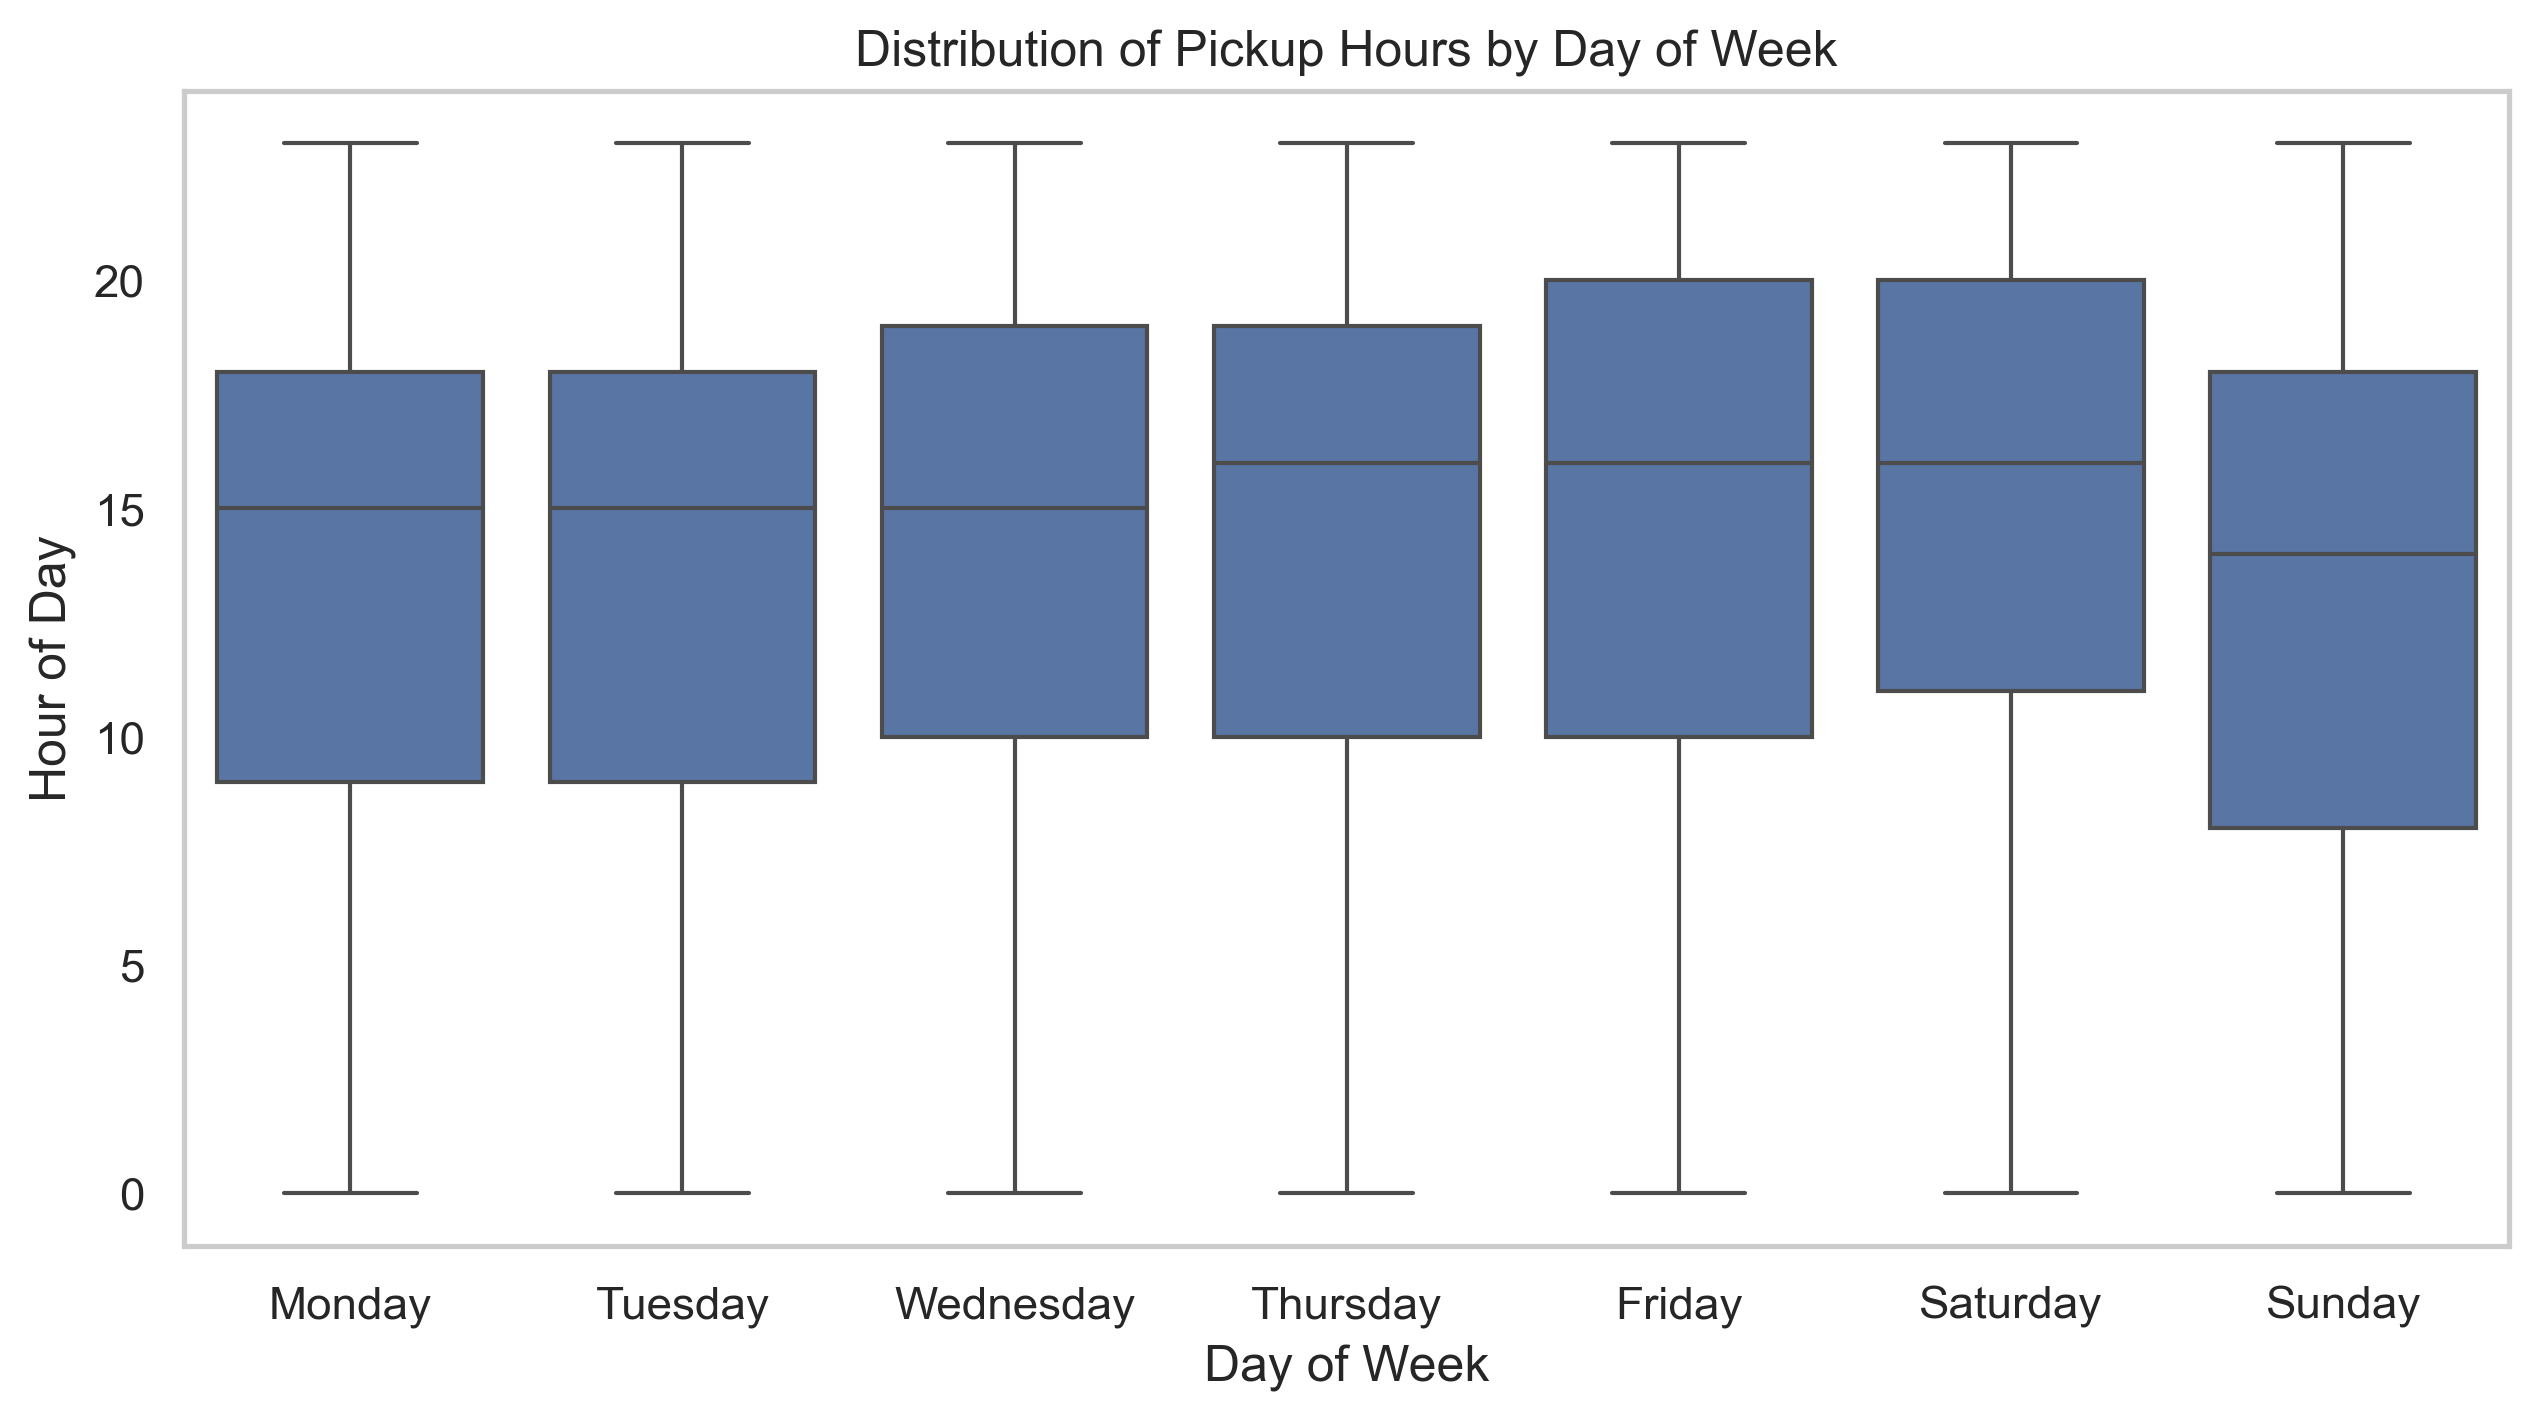

In [28]:
plt.figure(figsize=(10, 5))
# 전체 그래프의 크기를 가로 10인치, 세로 5인치로 설정함  
# 요일별 픽업 시간 분포를 충분히 가로로 펼쳐 보여주기 위한 비율 설정임  

sns.boxplot(
    x="day_of_week",
    # x축에 'day_of_week' 값을 배치하여 요일별 카테고리로 시각화함  
    # 각 요일이 하나의 그룹이 되어 시간 분포가 수직으로 표현됨  

    y="hour",
    # y축에 픽업 발생 시각(hour)을 배치함  
    # 시간은 0시부터 23시까지의 정수 값이며, 박스플롯을 통해 분포의 범위 및 중앙값을 표현함  

    data=df,
    # 입력 데이터로 전체 우버 호출 데이터프레임(df)을 사용함  

    order=ordered_days
    # 요일 순서를 월요일부터 일요일까지 명시적으로 지정함  
    # 기본 정렬인 알파벳 순이 아닌 실제 주간 흐름에 맞춘 시각화를 구성함  
)
# 요일별 픽업 발생 시각 분포를 박스플롯으로 시각화함  
# 각 박스는 해당 요일의 시간 데이터에 대해 중앙값, 사분위수, 이상치를 요약하여 보여줌  

plt.title("Distribution of Pickup Hours by Day of Week")
# 그래프의 상단 제목을 설정함  
# 이 시각화가 요일별 시간대 기반 픽업 분포를 나타낸다는 것을 사용자에게 전달함  

plt.xlabel("Day of Week")
# x축 레이블을 'Day of Week'로 설정함  
# 수평축이 요일 범주임을 명확히 전달함  

plt.ylabel("Hour of Day")
# y축 레이블을 'Hour of Day'로 설정함  
# 수직축이 시간(0~23시)임을 사용자에게 설명함  

plt.grid(axis='y')
# y축 방향으로만 격자선을 추가함  
# 각 요일의 시간대 범위를 해석할 때 기준선을 제공하여 가독성을 높임  

plt.show()
# 구성된 박스플롯 그래프를 출력함  
# 사용자에게 요일별 시간 분포의 패턴을 시각적으로 전달함  
